# Problems: Map the Word-Problem Catalog with t-SNE

The Problems catalog contains packaged textual design briefs as well as executable
decision, optimization, and grammar problems. This notebook maps the available
textual, or word, problems from their catalog summaries. It uses only local data:
TF-IDF represents each title, summary, and tag set, then seeded t-SNE projects those
vectors into two dimensions.

## Setup

Open this notebook in VS Code, select the environment used for the tutorial, and
install the focused package plus the two plotting dependencies:

```bash
python -m pip install design-research-problems==0.5.0 matplotlib scikit-learn
```

Run the cells from top to bottom. Every result shown below was captured with the
published package set and no network access.

## Step 1: Load only packaged text problems

`search_problem_summaries` avoids loading 126 complete prompt packets. Each compact
record still contains the title, short summary, tags, and taxonomy needed here.

In [1]:
from collections import Counter

import design_research_problems as problems
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

word_problems = problems.search_problem_summaries(kind=problems.ProblemKind.TEXT)
print(f"Packaged text problems: {len(word_problems)}")
for item in word_problems[:3]:
    print(f"- {item.problem_id}: {item.title}")

Packaged text problems: 126
- ideation_3d_printable_wind_turbine_tower: 3D-Printable Wind Turbine Tower
- ideation_accessible_drinking_fountain: Drinking Fountain for a Public Park
- ideation_accessible_drinking_fountain_derivative: Accessible Drinking Fountain (Derivative)


## Step 2: Turn catalog text into a local feature matrix

The representation is intentionally transparent. Unigrams and bigrams occurring in
at least two briefs become TF-IDF features; no hosted embedding model is involved.

In [2]:
documents = [f"{item.title}. {item.summary} Tags: {' '.join(item.tags)}" for item in word_problems]
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=600,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z-]+\b",
)
tfidf = vectorizer.fit_transform(documents)
print(f"TF-IDF matrix: {tfidf.shape[0]} problems x {tfidf.shape[1]} features")
print("Sample features:", ", ".join(vectorizer.get_feature_names_out()[:10]))

TF-IDF matrix: 126 problems x 508 features
Sample features: abstract, access, accessibility, accessibility consumer, accessibility door, accessibility infrastructure, accessibility retrieval, accessibility-focused, accidents, adapted


## Step 3: Compute a reproducible t-SNE projection

The fixed random state makes this release's map repeatable. Perplexity 20 is small
enough for 126 records while still describing neighborhoods larger than pairs of
nearly identical prompts.

In [3]:
coordinates = TSNE(
    n_components=2,
    perplexity=20,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(tfidf.toarray())
constraint_types = [item.constraint_nature or "unspecified" for item in word_problems]
print("Projection shape:", coordinates.shape)
print("Constraint labels:", dict(sorted(Counter(constraint_types).items())))

Projection shape: (126, 2)
Constraint labels: {'embedded-constraints': 75, 'informal': 13, 'open': 38}


## Step 4: Plot the catalog

Color comes from the catalog's `constraint_nature` field, not from a category inferred
after seeing the projection. A few evenly spaced titles provide landmarks without
covering the point cloud.

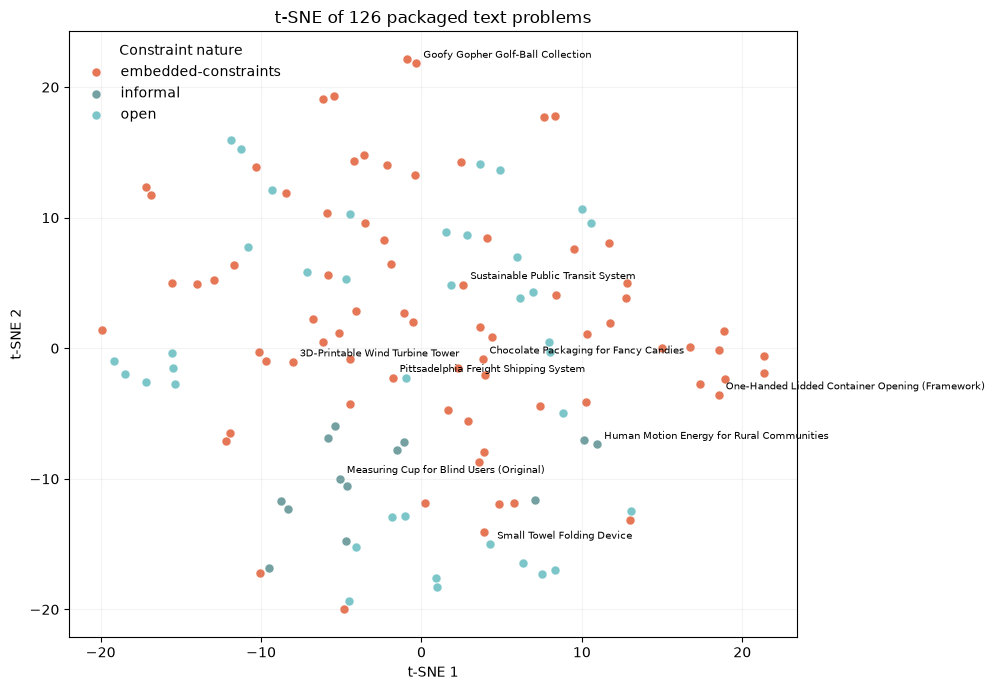

In [4]:
palette = {
    "embedded-constraints": "#df5127",
    "informal": "#4d8687",
    "open": "#57b7ba",
    "unspecified": "#6b7280",
}
figure, axis = plt.subplots(figsize=(10, 7))
for label in sorted(set(constraint_types)):
    mask = np.asarray([value == label for value in constraint_types])
    axis.scatter(
        coordinates[mask, 0],
        coordinates[mask, 1],
        s=42,
        alpha=0.78,
        color=palette[label],
        label=label,
        edgecolor="white",
        linewidth=0.5,
    )
for index in range(0, len(word_problems), 14):
    axis.annotate(
        word_problems[index].title,
        coordinates[index],
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7,
    )
axis.set(
    title=f"t-SNE of {len(word_problems)} packaged text problems",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
)
axis.legend(title="Constraint nature", frameon=False)
axis.grid(alpha=0.15)
figure.tight_layout()
plt.show()

## Step 5: Inspect one local neighborhood

t-SNE is a visualization, not a metric model: nearby points are useful leads, while
large global distances should not be over-interpreted. This final cell lists the five
nearest plotted neighbors of one familiar brief for follow-up catalog inspection.

In [5]:
query_index = next(
    index for index, item in enumerate(word_problems) if item.title == "Bicycle Safety Lock"
)
distances = np.linalg.norm(coordinates - coordinates[query_index], axis=1)
neighbor_indices = np.argsort(distances)[1:6]
print("Bicycle Safety Lock neighborhood:")
for index in neighbor_indices:
    print(f"- {word_problems[index].title} (distance={distances[index]:.2f})")

Bicycle Safety Lock neighborhood:
- Car-Mounted Bicycle Rack (distance=1.96)
- Disposable Spill-Proof Coffee Cup (distance=2.94)
- Pittsadelphia Freight Shipping System (distance=3.35)
- Motorized Can Crusher (distance=3.43)
- Future Personal Entertainment System (distance=4.04)


## Next steps

Change the document representation, t-SNE perplexity, or catalog filter and rerun the
projection. Use `get_problem(...)` only after the map or search results identify the
full prompt packet needed by a study.